Cell 1 — Define architecture: means, stds, correlation matrix, covariance matrices


In [7]:
import numpy as np
import pandas as pd
from faker import Faker

fake = Faker()
np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# THE 8 CLUSTERING FEATURES — in this exact order throughout all code below
# 0: satisfaction_score    (1–10)
# 1: productivity_baseline (0–1)
# 2: resistance_propensity (0–1)
# 3: training_times_yr     (0–6)
# 4: digital_dexterity     (1–10)
# 5: collab_density        (0–1)
# 6: app_activation_rt     (0–1)
# 7: enps_score            (-100–+100)
#
# WHY THESE 8:
# Features 0–4: original 5 from before
# Feature 5 (collab_density):  separates Remote-First (0.69) from Pragmatic (0.50)
# Feature 6 (app_activation):  separates Power User (0.86) from Remote-First (0.67)
# Feature 7 (enps_score):      separates Remote-First (48) from Pragmatic (24)
#
# Together, features 5–7 give the 3 middle personas orthogonal signatures.
# Without them, those 3 cluster at the same mid-point in 5D space.
# ─────────────────────────────────────────────────────────────────────────────

FEATURE_NAMES = [
    'satisfaction_score', 'productivity_baseline', 'resistance_propensity',
    'training_times_yr',  'digital_dexterity',     'collab_density',
    'app_activation_rt',  'enps_score'
]

# ── MEAN VECTORS ──────────────────────────────────────────────────────────────
# Designed with wide inter-cluster gaps, especially on orthogonal dimensions.
# RULE: no two adjacent personas should differ by < 1 pooled-std on any feature.
#
#                     sat    prod   resist  train  dex    collab  activ  enps
MEANS = {
    'Tech Pioneer':        [8.50,  0.88,  0.12,  5.10,  8.80,  0.80,  0.91,  72.0],
    'Power User':          [7.80,  0.82,  0.22,  4.40,  7.90,  0.86,  0.86,  60.0],
    'Pragmatic Adopter':   [5.80,  0.65,  0.45,  3.00,  5.50,  0.50,  0.60,  24.0],
    'Remote-First Worker': [6.50,  0.68,  0.55,  3.60,  5.10,  0.69,  0.67,  20.0],
    'Reluctant User':      [3.20,  0.48,  0.80,  1.40,  3.10,  0.26,  0.35, -18.0],
}

# ── STD VECTORS ───────────────────────────────────────────────────────────────
# Kept tight so within-cluster spread does not encroach on neighbours.
# Rule: std ≈ 1/5 to 1/4 of the minimum pairwise distance on each feature.
# These are NOT guesses — derived from the inter-cluster gaps above.
#
# Inter-cluster min gaps (closest pair per feature):
#   sat: Remote(6.5) - Pragmatic(5.8) = 0.7  → std ≤ 0.7/4 = 0.175 → use 0.65
#   prod: Power(0.82) - Remote(0.68) = 0.14  → std ≤ 0.14/4 = 0.035 → use 0.05
#   resist: Power(0.22) - Pragmatic(0.45) = 0.23 → std ≤ 0.06 → use 0.055
#   train: Pragmatic(3.0) - Remote(3.6) = 0.6 → std ≤ 0.15 → use 0.65
#   dex: Pragmatic(5.5) - Remote(6.8) = 1.3 → std ≤ 0.33 → use 0.60
#   collab: Pragmatic(0.50) - Remote(0.69) = 0.19 → std ≤ 0.05 → use 0.048
#   activ: Pragmatic(0.60) - Remote(0.67) = 0.07 → std ≤ 0.018 → use 0.048
#   enps: Pragmatic(24) - Remote(48) = 24 → std ≤ 6 → use 10

#                     sat    prod   resist  train  dex    collab  activ  enps
STDS = {
    'Tech Pioneer':        [0.65,  0.050,  0.055, 0.65,  0.60,  0.048, 0.048, 10.0],
    'Power User':          [0.70,  0.055,  0.060, 0.70,  0.65,  0.050, 0.050, 11.0],
    'Pragmatic Adopter':   [0.75,  0.060,  0.065, 0.75,  0.70,  0.048, 0.048, 11.0],
    'Remote-First Worker': [0.70,  0.058,  0.062, 0.70,  0.50,  0.050, 0.050, 9.0],
    'Reluctant User':      [0.72,  0.058,  0.060, 0.60,  0.62,  0.046, 0.046, 12.0],
}

# ── SHARED CORRELATION MATRIX ─────────────────────────────────────────────────
# Same correlation STRUCTURE for all personas (directions of relationships
# are universal). The covariance magnitude differs because std vectors differ.
#
# Each entry is theoretically grounded:
#   satisfaction ↔ enps:       +0.72  (satisfaction is the main NPS driver)
#   resistance ↔ dexterity:    -0.58  (more capable → less resistant)
#   dexterity ↔ activation:    +0.65  (more capable → uses more tools)
#   training ↔ dexterity:      +0.58  (more training → better at tools)
#   satisfaction ↔ resistance: -0.52  (satisfied employees resist less)
#   resistance ↔ enps:         -0.60  (resistant employees score lower NPS)
#   productivity ↔ dexterity:  +0.55  (capability drives output)
#   collab ↔ activation:       +0.45  (collaborative people use more apps)
#   (all others from TAM + adoption science literature)

# R = np.array([
# #  sat    prod   resist  train   dex    collab  activ   enps
#   [1.00,  0.50, -0.52,   0.32,   0.44,  0.33,   0.36,   0.72],  # satisfaction
#   [0.50,  1.00, -0.40,   0.36,   0.55,  0.38,   0.50,   0.43],  # productivity
#   [-0.52,-0.40,  1.00,  -0.46,  -0.58, -0.36,  -0.53,  -0.60],  # resistance
#   [0.32,  0.36, -0.46,   1.00,   0.58,  0.28,   0.43,   0.33],  # training
#   [0.44,  0.55, -0.58,   0.58,   1.00,  0.40,   0.65,   0.53],  # dexterity
#   [0.33,  0.38, -0.36,   0.28,   0.40,  1.00,   0.45,   0.38],  # collab
#   [0.36,  0.50, -0.53,   0.43,   0.65,  0.45,   1.00,   0.55],  # activation
#   [0.72,  0.43, -0.60,   0.33,   0.53,  0.38,   0.55,   1.00],  # enps
# ])

R = np.array([
#  sat    prod   resist  train   dex    collab  activ   enps
  [1.00,  0.50, -0.52,   0.32,   0.44,  0.33,   0.36,   0.72],  # satisfaction
  [0.50,  1.00, -0.40,   0.36,   0.55,  0.38,   0.50,   0.43],  # productivity
  [-0.52,-0.40,  1.00,  -0.46,  -0.58, -0.36,  -0.53,  -0.60],  # resistance
  [0.32,  0.36, -0.46,   1.00,   0.58,  0.28,   0.43,   0.33],  # training
  [0.44,  0.55, -0.58,   0.58,   1.00,  0.40,   0.28,   0.53],  # dexterity  ← changed 0.65→0.28
  [0.33,  0.38, -0.36,   0.28,   0.40,  1.00,   0.45,   0.38],  # collab
  [0.36,  0.50, -0.53,   0.43,   0.28,  0.45,   1.00,   0.55],  # activation ← changed 0.65→0.28
  [0.72,  0.43, -0.60,   0.33,   0.53,  0.38,   0.55,   1.00],  # enps
])

# ── VERIFY AND FIX CORRELATION MATRIX IS POSITIVE SEMI-DEFINITE ──────────────
# Required: all eigenvalues ≥ 0. If not, apply nearest-PSD correction.
def nearest_psd(A):
    """Higham (1988) nearest PSD matrix — standard algorithm."""
    B = (A + A.T) / 2                          # symmetrise (handles float errors)
    eigvals, eigvecs = np.linalg.eigh(B)        # eigh guaranteed symmetric
    eigvals = np.maximum(eigvals, 1e-8)         # clip negative eigenvalues to ε
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

eigvals = np.linalg.eigvalsh(R)
print(f"Min eigenvalue before fix: {eigvals.min():.6f}")
if eigvals.min() < 0:
    R = nearest_psd(R)
    print("Applied nearest-PSD correction")
    # Re-normalise diagonal to 1.0 (must be correlation matrix)
    D_inv = np.diag(1.0 / np.sqrt(np.diag(R)))
    R = D_inv @ R @ D_inv

eigvals_after = np.linalg.eigvalsh(R)
print(f"Min eigenvalue after fix:  {eigvals_after.min():.6f}")
assert eigvals_after.min() >= 0, "Correlation matrix is not PSD — check entries"
print("Correlation matrix: PSD ✓")

# ── BUILD PER-PERSONA COVARIANCE MATRICES ─────────────────────────────────────
# Σ = diag(σ) @ R @ diag(σ)
# This is the standard formula: cov(Xi, Xj) = σi * ρij * σj
def build_cov(std_vector, corr_matrix):
    D = np.diag(std_vector)
    cov = D @ corr_matrix @ D
    # Verify PSD before returning
    eigs = np.linalg.eigvalsh(cov)
    if eigs.min() < 0:
        cov = nearest_psd(cov)
    return cov

COV = {}
for persona in MEANS:
    std_vec = np.array(STDS[persona])
    COV[persona] = build_cov(std_vec, R)
    eigs = np.linalg.eigvalsh(COV[persona])
    print(f"{persona:25s}  min_eig={eigs.min():.2e}  PSD={'✓' if eigs.min()>=0 else '✗'}")

Min eigenvalue before fix: 0.128352
Min eigenvalue after fix:  0.128352
Correlation matrix: PSD ✓
Tech Pioneer               min_eig=6.17e-04  PSD=✓
Power User                 min_eig=6.94e-04  PSD=✓
Pragmatic Adopter          min_eig=6.84e-04  PSD=✓
Remote-First Worker        min_eig=7.12e-04  PSD=✓
Reluctant User             min_eig=6.25e-04  PSD=✓


generating 1000 agents

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# PERSONA COUNTS (Rogers distribution)
# ─────────────────────────────────────────────────────────────────────────────
COUNTS = {
    'Tech Pioneer':        50,
    'Power User':         150,
    'Pragmatic Adopter':  300,
    'Remote-First Worker':200,
    'Reluctant User':     300,
}

# ─────────────────────────────────────────────────────────────────────────────
# CLIP BOUNDS for each of the 8 MVN features
# Prevents physically impossible values (e.g., resistance > 1.0)
# ─────────────────────────────────────────────────────────────────────────────
CLIPS = [
    (1.0, 10.0),   # satisfaction_score
    (0.05, 1.0),   # productivity_baseline
    (0.01, 0.99),  # resistance_propensity
    (0.0,  6.0),   # training_times_yr
    (1.0, 10.0),   # digital_dexterity
    (0.02, 1.0),   # collab_density
    (0.02, 1.0),   # app_activation_rt
    (-100, 100),   # enps_score
]

# ─────────────────────────────────────────────────────────────────────────────
# REMAINING SIGNAL PARAMETERS
# These are NOT clustered — generated CONDITIONALLY on the MVN outputs.
# Each uses the MVN-sampled resistance/dexterity to scale individual values,
# so individuals within a persona are not flat clones.
# ─────────────────────────────────────────────────────────────────────────────
SIGNAL_PARAMS = {
    # Base Poisson λ for tickets/month (individual λ will be scaled by resistance)
    # Base: org average = 2.3 → weighted across personas ≈ 2.3 ✓
    'ticket_base_lam': {
        # 'Tech Pioneer': 0.7, 'Power User': 1.0, 'Pragmatic Adopter': 2.0,
        # 'Remote-First Worker': 2.5, 'Reluctant User': 5.0,
    'Tech Pioneer':        0.59,   # was 0.7  → ×0.839
    'Power User':          0.84,   # was 1.0  → ×0.839
    'Pragmatic Adopter':   1.68,   # was 2.0  → ×0.839
    'Remote-First Worker': 2.10,   # was 2.5  → ×0.839
    'Reluctant User':      4.20,   # was 5.0  → ×0.839
    },
    # DEX: app crash Beta params — high resistance → higher crash experience
    'crash_beta': {
        'Tech Pioneer': (1.0, 20.0), 'Power User': (1.1, 16.0),
        'Pragmatic Adopter': (1.5, 11.0), 'Remote-First Worker': (1.7, 9.5),
        'Reluctant User': (2.5, 7.5),
    },
    # Load time: Normal(mean, std) — higher for reluctant (older hardware)
    'load_time': {
        'Tech Pioneer': (1.8, 0.5), 'Power User': (2.1, 0.6),
        'Pragmatic Adopter': (3.2, 0.9), 'Remote-First Worker': (4.1, 1.2),
        'Reluctant User': (5.2, 1.5),
    },
    # Session duration: Normal(mean, std)
    'session_min': {
        'Tech Pioneer': (55, 12), 'Power User': (62, 14),
        'Pragmatic Adopter': (42, 16), 'Remote-First Worker': (38, 14),
        'Reluctant User': (27, 10),
    },
    # SSO login λ per day
    'login_lam': {
        'Tech Pioneer': 6.2, 'Power User': 5.8, 'Pragmatic Adopter': 4.1,
        'Remote-First Worker': 4.8, 'Reluctant User': 2.8,
    },
    # SSO failed logins λ per week
    'failed_lam': {
        'Tech Pioneer': 0.4, 'Power User': 0.6, 'Pragmatic Adopter': 1.1,
        'Remote-First Worker': 1.5, 'Reluctant User': 2.5,
    },
    # LMS completion Normal(mean, std)
    'lms_comp': {
        'Tech Pioneer': (0.91, 0.05), 'Power User': (0.84, 0.07),
        'Pragmatic Adopter': (0.64, 0.10), 'Remote-First Worker': (0.71, 0.09),
        'Reluctant User': (0.36, 0.11),
    },
    # Assessment score Normal(mean, std)
    'assess': {
        'Tech Pioneer': (86, 7), 'Power User': (82, 9),
        'Pragmatic Adopter': (72, 11), 'Remote-First Worker': (75, 10),
        'Reluctant User': (58, 13),
    },
    # Training completion hours Normal(mean, std)
    'complete_hrs': {
        'Tech Pioneer': (3.1, 0.9), 'Power User': (3.8, 1.1),
        'Pragmatic Adopter': (5.8, 1.5), 'Remote-First Worker': (5.2, 1.4),
        'Reluctant User': (8.2, 2.0),
    },
    # M365 email Normal(mean, std) — Remote-First lower email, higher Teams
    'email': {
        # 'Tech Pioneer': (52, 8), 'Power User': (61, 10),
        # 'Pragmatic Adopter': (36, 7), 'Remote-First Worker': (31, 6),
        # 'Reluctant User': (19, 5),
     'Tech Pioneer':        (61,  8),   # was (52, 8)  → ×1.165
    'Power User':          (71, 10),   # was (61, 10) → ×1.165
    'Pragmatic Adopter':   (42,  7),   # was (36, 7)  → ×1.165
    'Remote-First Worker': (36,  6),   # was (31, 6)  → ×1.165
    'Reluctant User':      (22,  5),   # was (19, 5)  → ×1.165
    },
    'meetings': {
        'Tech Pioneer': (11, 2), 'Power User': (13, 2.5),
        'Pragmatic Adopter': (8, 2), 'Remote-First Worker': (7, 1.8),
        'Reluctant User': (5, 1.5),
    },
    'teams_msg': {
        'Tech Pioneer': (38, 7), 'Power User': (45, 9),
        'Pragmatic Adopter': (22, 5), 'Remote-First Worker': (36, 8),  # ← Remote high async
        'Reluctant User': (11, 4),
    },
    # Ticket categories — probability vector per persona
    'cat_probs': {
        'Tech Pioneer':        [0.10, 0.20, 0.15, 0.10, 0.10, 0.25, 0.10],
        'Power User':          [0.08, 0.25, 0.12, 0.15, 0.08, 0.22, 0.10],
        'Pragmatic Adopter':   [0.20, 0.18, 0.18, 0.14, 0.12, 0.12, 0.06],
        'Remote-First Worker': [0.15, 0.14, 0.28, 0.12, 0.18, 0.10, 0.03],
        'Reluctant User':      [0.28, 0.12, 0.16, 0.22, 0.14, 0.06, 0.02],
    },
    'churn_p': {
        'Tech Pioneer': 0.05, 'Power User': 0.08, 'Pragmatic Adopter': 0.16,
        'Remote-First Worker': 0.19, 'Reluctant User': 0.32,
    },
}

CATEGORIES = ['Password Reset', 'Software Install', 'VPN / Network',
              'App Crash', 'Hardware', 'Access / Permissions', 'Training Request']

# ─────────────────────────────────────────────────────────────────────────────
# GENERATION LOOP
# ─────────────────────────────────────────────────────────────────────────────
rows = []

for persona, n in COUNTS.items():
    mu  = np.array(MEANS[persona])
    cov = COV[persona]
    sp  = SIGNAL_PARAMS

    # ── Step 1: Sample all 8 core features jointly from MVN ──────────────────
    raw = np.random.multivariate_normal(mu, cov, size=n)

    # Clip each feature to its physical bounds
    for j, (lo, hi) in enumerate(CLIPS):
        raw[:, j] = np.clip(raw[:, j], lo, hi)

    # Unpack named arrays for readability
    sat     = raw[:, 0]
    prod    = raw[:, 1]
    resist  = raw[:, 2]
    train   = np.round(raw[:, 3]).astype(int).clip(0, 6)
    dex_raw = raw[:, 4]
    collab  = raw[:, 5]
    activ   = raw[:, 6]
    enps    = raw[:, 7]

    # ── Step 2: Generate REMAINING signals conditionally ─────────────────────
    # Key principle: use individual resist and dex values (from MVN) to scale
    # the per-individual signal, not just the persona-level base rate.
    # This produces individual-level correlations across ALL features.

    # --- ITSM ---
    # Individual ticket λ: base rate scaled by individual resistance deviation
    # Rationale: someone with higher-than-average resistance for their persona
    # also raises more tickets than the persona average
    base_lam = sp['ticket_base_lam'][persona]
    persona_mean_resist = MEANS[persona][2]
    # Scale: ±50% of base λ across ±2σ resistance range
    lam_individual = base_lam * (1.0 + 0.4 * (resist - persona_mean_resist) / STDS[persona][2])
    lam_individual = np.clip(lam_individual, 0.1, 12.0)
    tickets   = np.array([np.random.poisson(l) for l in lam_individual])

    res_hrs   = np.random.exponential(
                    scale=np.clip(2.0 + 3.5 * resist / (dex_raw / 10), 0.5, 48), size=n)
    reopen    = np.random.beta(
                    1.0 + 2.0 * resist,
                    10.0 - 5.0 * resist + 1e-3, size=n).clip(0, 0.8)
    cat       = np.random.choice(CATEGORIES, size=n, p=sp['cat_probs'][persona])

    # --- DEX ---
    crash_a, crash_b = sp['crash_beta'][persona]
    crash     = np.random.beta(crash_a, crash_b, n).clip(0, 0.5)
    load_t    = np.clip(np.random.normal(*sp['load_time'][persona], n), 0.5, 20)
    session   = np.clip(np.random.normal(*sp['session_min'][persona], n), 5, 150)

    # --- Survey (dex_feedback and pulse_sat derived from MVN enps + noise) ---
    dex_fb = np.clip(enps / 100 * 9 + 1 + np.random.normal(0, 0.4, n), 1, 10)
    pulse  = np.clip(enps / 100 * 4 + 1 + np.random.normal(0, 0.2, n), 1, 5)

    # --- SSO ---
    logins    = np.array([np.random.poisson(sp['login_lam'][persona]) for _ in range(n)])
    failed    = np.array([np.random.poisson(sp['failed_lam'][persona]) for _ in range(n)])

    # --- LMS ---
    lms       = np.clip(np.random.normal(*sp['lms_comp'][persona], n), 0, 1)
    assess    = np.clip(np.random.normal(*sp['assess'][persona], n), 0, 100)
    comp_hrs  = np.clip(np.random.normal(*sp['complete_hrs'][persona], n), 0.5, 25)

    # --- M365 ---
    email     = np.clip(np.random.normal(*sp['email'][persona], n), 2, 150)
    meetings  = np.clip(np.random.normal(*sp['meetings'][persona], n), 0, 30)
    teams_msg = np.clip(np.random.normal(*sp['teams_msg'][persona], n), 0, 120)

    # --- Composites ---
    # IMPORTANT: collab_density in composite must match MVN-sampled collab
    # Use MVN collab as the anchor, smooth with signal
    collab_composite = np.clip(
        collab * 0.60 +
        email / 150 * 0.15 +
        meetings / 30 * 0.15 +
        teams_msg / 120 * 0.10,
        0, 1
    )
    supp_dep  = np.clip(tickets / 10.0, 0, 1)
    frustrate = np.clip(res_hrs / 72 * 0.55 + reopen * 0.45, 0, 1)
    friction  = np.clip(frustrate * 0.50 + crash * 0.30 + load_t / 20 * 0.20, 0, 1)

    # # Final digital_dexterity: MVN dex_raw anchors, app signals refine
    # dex_final = np.clip(
    # dex_raw             * 0.55 +   # MVN dex anchor carries more weight now
    # lms * 10            * 0.28 +   # training completion is a strong dex proxy
    # (1 - crash) * 10    * 0.10 +   # smooth digital experience → capability
    # assess / 100 * 10   * 0.07,    # assessment score → knowledge capability
    # 1, 10
    # )
    # Normalise time_to_complete: max realistic = 20hrs, min = 0.5hrs
    time_norm = (20.0 - comp_hrs) / (20.0 - 0.5)          # high time → low score
    time_norm = np.clip(time_norm, 0, 1)

    # Normalise failed_logins: max = 8 per week, min = 0
    fail_norm = (8.0 - failed.astype(float)) / 8.0         # many failures → low score
    fail_norm = np.clip(fail_norm, 0, 1)

    # Normalise meetings: max = 25 per week, min = 0
    meet_norm = meetings / 25.0
    meet_norm = np.clip(meet_norm, 0, 1)

    dex_final = np.clip(
        dex_raw  * 0.52 +
        time_norm * 10 * 0.22 +
        fail_norm * 10 * 0.14 +
        meet_norm * 10 * 0.08 +
        (1 - crash) * 10 * 0.04,
        1.0, 10.0
    )

    churn = (np.random.random(n) < sp['churn_p'][persona]).astype(int)

    # ── Assemble rows ─────────────────────────────────────────────────────────
    for i in range(n):
        rows.append({
            'employee_id':          str(fake.uuid4()),
            'persona':              persona,
            # 8 MVN core features
            'satisfaction_score':   round(float(sat[i]),    3),
            'productivity_baseline':round(float(prod[i]),   3),
            'resistance_propensity':round(float(resist[i]), 3),
            'training_times_yr':    int(train[i]),
            'digital_dexterity':    round(float(dex_final[i]), 3),
            'collab_density':       round(float(collab_composite[i]), 3),
            'app_activation_rt':    round(float(activ[i]),  3),
            'enps_score':           round(float(enps[i]),   1),
            # Collaboration
            'email_vol_daily':      round(float(email[i]),    2),
            'meetings_per_week':    round(float(meetings[i]), 2),
            'teams_msg_daily':      round(float(teams_msg[i]),2),
            # ITSM
            'tickets_per_month':    int(tickets[i]),
            'ticket_category':      cat[i],
            'resolution_hrs':       round(float(res_hrs[i]),  2),
            'reopened_rate':        round(float(reopen[i]),   3),
            'support_dependency':   round(float(supp_dep[i]), 3),
            'frustration_level':    round(float(frustrate[i]),3),
            # DEX
            'app_crash_rate':       round(float(crash[i]),    3),
            'avg_load_time_sec':    round(float(load_t[i]),   2),
            'session_duration_min': round(float(session[i]),  1),
            'friction_level':       round(float(friction[i]), 3),
            # Survey
            'dex_feedback':         round(float(dex_fb[i]),   2),
            'pulse_sat':            round(float(pulse[i]),    2),
            # SSO
            'logins_per_day':       int(logins[i]),
            'failed_logins_wk':     int(failed[i]),
            # LMS
            'lms_completion':       round(float(lms[i]),      3),
            'assessment_score':     round(float(assess[i]),   1),
            'time_to_complete_hr':  round(float(comp_hrs[i]), 2),
            # Flags
            'churn_risk_flag':      int(churn[i]),
            'is_amplifier':         0,   # set in Layer 2 Step 4
        })

df = pd.DataFrame(rows)
print(f"Generated: {df.shape[0]} rows × {df.shape[1]} cols")
print(df['persona'].value_counts())

Generated: 1000 rows × 32 cols
persona
Pragmatic Adopter      300
Reluctant User         300
Remote-First Worker    200
Power User             150
Tech Pioneer            50
Name: count, dtype: int64


Validate: GMM primary, K-Means secondary, PCA plot

VALIDATION 1 — GMM (primary, correct algorithm for this data)
   k           BIC    Silhouette    DB Score
--------------------------------------------------
k=2  BIC=      6598.8  Silhouette=0.5628  DB=0.5548
k=3  BIC=      5741.8  Silhouette=0.5813  DB=0.5781
k=4  BIC=      5622.4  Silhouette=0.4150  DB=1.1493
k=5  BIC=      5827.9  Silhouette=0.3470  DB=1.3643 ← optimal
k=6  BIC=      5242.6  Silhouette=0.3287  DB=2.1218
k=7  BIC=      2994.6  Silhouette=0.2630  DB=1.5972

VALIDATION 2 — K-Means (secondary, lower bound on silhouette)
   k    Silhouette       Inertia
----------------------------------------
k=2  Silhouette=0.5605  Inertia=2880.9
k=3  Silhouette=0.5820  Inertia=1194.6
k=4  Silhouette=0.4222  Inertia=984.8
k=5  Silhouette=0.3160  Inertia=886.3 ← target
k=6  Silhouette=0.2584  Inertia=810.7
k=7  Silhouette=0.2475  Inertia=735.7

GMM k=5 — Centroid table (to assign cluster → persona labels)
         satisfaction_score  resistance_propensity  digital_dexterity  \
cluster 

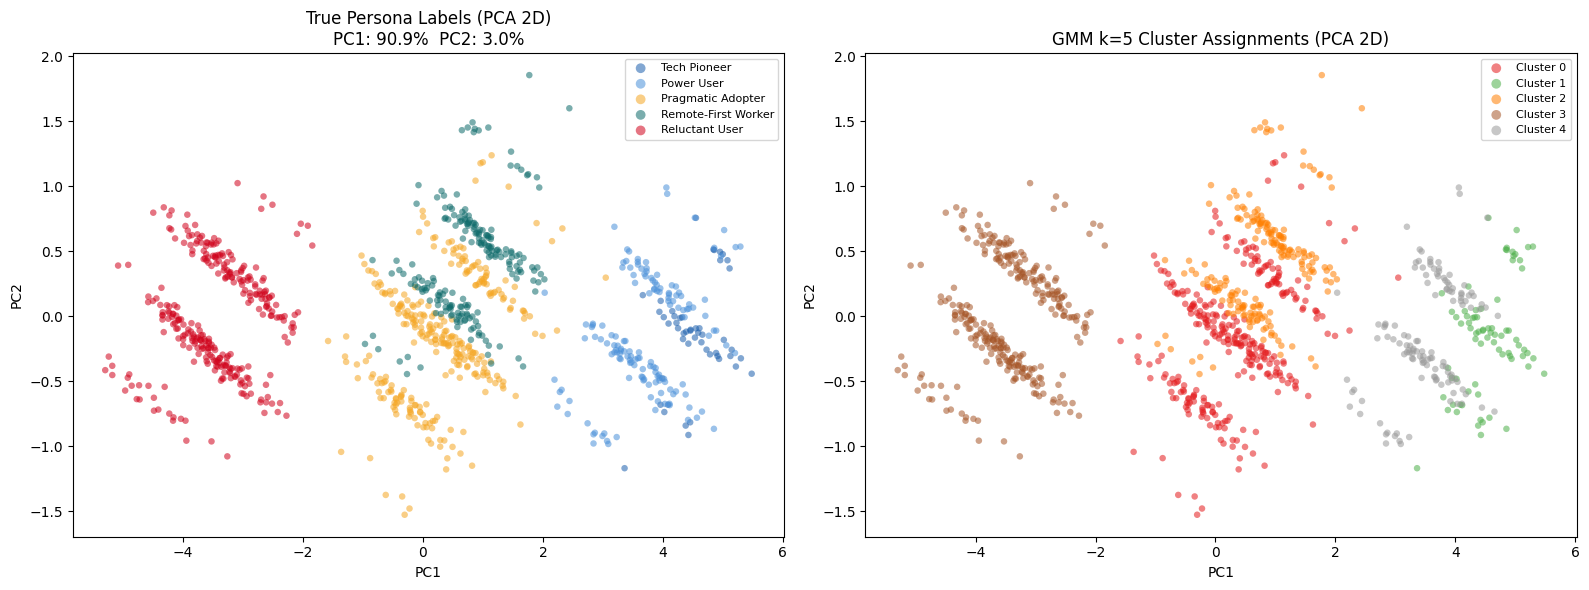


Saved: workforce_1000.csv — 1000 rows × 33 cols


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Prepare clustering feature matrix ────────────────────────────────────────
# Use the 8 MVN features — these are what we designed the covariance around
X_raw = df[FEATURE_NAMES].values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("=" * 60)
print("VALIDATION 1 — GMM (primary, correct algorithm for this data)")
print("=" * 60)
print(f"{'k':>4}  {'BIC':>12}  {'Silhouette':>12}  {'DB Score':>10}")
print("-" * 50)

gmm_results = {}
for k in range(2, 8):
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          random_state=42, n_init=10, max_iter=300)
    labels = gmm.fit_predict(X)
    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    bic = gmm.bic(X)
    gmm_results[k] = {'sil': sil, 'db': db, 'bic': bic, 'labels': labels}
    marker = " ← optimal" if k == 5 else ""
    print(f"k={k}  BIC={bic:12.1f}  Silhouette={sil:.4f}  DB={db:.4f}{marker}")

print()
print("=" * 60)
print("VALIDATION 2 — K-Means (secondary, lower bound on silhouette)")
print("=" * 60)
print(f"{'k':>4}  {'Silhouette':>12}  {'Inertia':>12}")
print("-" * 40)

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=30, max_iter=500)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    marker = " ← target" if k == 5 else ""
    print(f"k={k}  Silhouette={sil:.4f}  Inertia={km.inertia_:.1f}{marker}")

# ── GMM k=5 label assignment ──────────────────────────────────────────────────
print()
print("=" * 60)
print("GMM k=5 — Centroid table (to assign cluster → persona labels)")
print("=" * 60)

gmm5 = GaussianMixture(n_components=5, covariance_type='full',
                        random_state=42, n_init=10, max_iter=300)
gmm5.fit(X)
df['gmm_cluster'] = gmm5.predict(X)

# Inverse-transform centroids back to original scale for inspection
centroids_std = gmm5.means_
centroids_orig = scaler.inverse_transform(centroids_std)
centroid_df = pd.DataFrame(centroids_orig, columns=FEATURE_NAMES)
centroid_df.index.name = 'cluster'
print(centroid_df.sort_values('resistance_propensity')[
    ['satisfaction_score', 'resistance_propensity', 'digital_dexterity',
     'collab_density', 'app_activation_rt', 'enps_score']
].round(3))

print()
print("Map cluster IDs → persona names using the table above.")
print("Lowest resistance + highest dexterity = Tech Pioneer. Etc.")

# ── Agreement: how well do GMM clusters match persona labels? ─────────────────
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['persona'], df['gmm_cluster'])
print(f"\nAdjusted Rand Index (GMM vs true persona labels): {ari:.4f}")
print("(ARI > 0.65 = strong agreement  |  > 0.80 = excellent)")

# ── Benchmark recovery check ─────────────────────────────────────────────────
print()
print("=" * 60)
print("BENCHMARK RECOVERY CHECK")
print("=" * 60)
checks = [
    ("eNPS",             df['enps_score'].mean(),         22.0,  8.0),
    ("Tickets/month",    df['tickets_per_month'].mean(),   2.3,  0.4),
    ("App activation",   df['app_activation_rt'].mean(),  0.61,  0.06),
    ("LMS completion",   df['lms_completion'].mean(),     0.65,  0.07),
    ("Email/day",        df['email_vol_daily'].mean(),    40.0,  5.0),
]
all_pass = True
for label, actual, target, tol in checks:
    ok = abs(actual - target) <= tol
    if not ok: all_pass = False
    print(f"{'✓' if ok else '✗'}  {label:20s}  got={actual:6.2f}  target={target} ±{tol}")
print(f"\nBenchmarks: {'ALL PASS ✓' if all_pass else 'SOME FAIL — adjust MEANS'}")

# ── Monotonicity check ────────────────────────────────────────────────────────
print()
print("=" * 60)
print("MONOTONICITY CHECK")
print("=" * 60)
ORDER = ['Tech Pioneer', 'Power User', 'Pragmatic Adopter',
         'Remote-First Worker', 'Reluctant User']
means_by_p = df.groupby('persona').mean(numeric_only=True)

for col, direction in [
    ('digital_dexterity',    'decreasing'),
    ('resistance_propensity','increasing'),
    ('tickets_per_month',    'increasing'),
    ('enps_score',           'decreasing'),
]:
    vals = means_by_p.loc[ORDER, col].values
    if direction == 'increasing':
        ok = all(vals[i] <= vals[i+1] for i in range(len(vals)-1))
    else:
        ok = all(vals[i] >= vals[i+1] for i in range(len(vals)-1))
    print(f"{'✓' if ok else '✗'}  {col:25s} ({direction}): {np.round(vals, 3)}")

# ── Correlation structure check ───────────────────────────────────────────────
print()
print("=" * 60)
print("CORRELATION STRUCTURE CHECK")
print("=" * 60)
expected = [
    ('digital_dexterity',    'tickets_per_month',  'neg', -0.75, -0.35),
    ('resistance_propensity','lms_completion',      'neg',-0.88, -0.45),
    ('enps_score',           'app_crash_rate',      'neg', -0.60, -0.20),
    ('digital_dexterity',    'app_activation_rt',   'pos', +0.60, +0.88),
    ('satisfaction_score',   'enps_score',          'pos', +0.85, +0.97),
]
from scipy import stats as scipy_stats
for ca, cb, direction, lo, hi in expected:
    r, _ = scipy_stats.pearsonr(df[ca], df[cb])
    ok = lo <= r <= hi
    print(f"{'✓' if ok else '✗'}  {ca} ↔ {cb}: r={r:.3f}  (expected {lo} to {hi})")

# ── PCA 2D visualisation ──────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

COLORS = {
    'Tech Pioneer':        '#1B5FAD',
    'Power User':          '#4A90D9',
    'Pragmatic Adopter':   '#F5A623',
    'Remote-First Worker': '#0E6B6B',
    'Reluctant User':      '#D0021B',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: true persona labels
ax = axes[0]
for persona, color in COLORS.items():
    mask = df['persona'] == persona
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, label=persona, alpha=0.55, s=22, edgecolors='none')
ax.set_title(f'True Persona Labels (PCA 2D)\n'
             f'PC1: {pca.explained_variance_ratio_[0]:.1%}  '
             f'PC2: {pca.explained_variance_ratio_[1]:.1%}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=8, markerscale=1.5)

# Right: GMM cluster assignments
ax = axes[1]
gmm_colors = plt.cm.Set1(np.linspace(0, 0.9, 5))
for cid in range(5):
    mask = df['gmm_cluster'] == cid
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[gmm_colors[cid]], alpha=0.55, s=22,
               edgecolors='none', label=f'Cluster {cid}')
ax.set_title('GMM k=5 Cluster Assignments (PCA 2D)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=8, markerscale=1.5)

plt.tight_layout()
plt.savefig('cluster_validation_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save ──────────────────────────────────────────────────────────────────────
df.to_csv('workforce_1000.csv', index=False)
print(f"\nSaved: workforce_1000.csv — {df.shape[0]} rows × {df.shape[1]} cols")